In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import cv2
import numpy as np




In [2]:
import kagglehub
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [3]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
  try:
    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    print("GPU is available and memory growth is set.")
  except RuntimeError as e:
    print(e)

GPU is available and memory growth is set.


In [4]:
IMG_HEIGHT = 150
IMG_WIDTH = 150
BATCH_SIZE = 32
EPOCHS = 10
DATA_DIR = '/kaggle/input/chest-xray-pneumonia/chest_xray'

In [5]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [6]:

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [7]:
try:
    train_generator = train_datagen.flow_from_directory(
        os.path.join(DATA_DIR, 'train'),
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='binary'
    )

    val_generator = val_datagen.flow_from_directory(
        os.path.join(DATA_DIR, 'val'),
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='binary'
    )

    test_generator = test_datagen.flow_from_directory(
        os.path.join(DATA_DIR, 'test'),
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='binary',
        shuffle=False  # Important for later evaluation
    )
except Exception as e:
    print(f"Error loading data: {e}")
    print("Please ensure your dataset is correctly organized at the specified path.")
    exit()

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [8]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),

    Dense(512, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,034,177 (72.61 MB)

 Trainable params: 19,034,177 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
print("\nStarting model training...")
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=val_generator,
    validation_steps=val_generator.samples // BATCH_SIZE
)


Starting model training...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 85s 488ms/step - accuracy: 0.7156 - loss: 0.6140 - val_accuracy: 0.5625 - val_loss: 0.8981
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 131s 444ms/step - accuracy: 0.8540 - loss: 0.3353 - val_accuracy: 0.7500 - val_loss: 0.5463
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 74s 451ms/step - accuracy: 0.8652 - loss: 0.3127 - val_accuracy: 0.7500 - val_loss: 0.4656
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 73s 446ms/step - accuracy: 0.8810 - loss: 0.2720 - val_accuracy: 0.8750 - val_loss: 0.3538
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 73s 445ms/step - accuracy: 0.9036 - loss: 0.2390 - val_accuracy: 0.6250 - val_loss: 0.7025
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 81s 440ms/step - accuracy: 0.8974 - loss: 0.2517 - val_accuracy: 0.6875 - val_loss: 1.1047
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 73s 447ms/step - accuracy: 0.8890 - loss: 0.2585 - val_accuracy: 0.7500 - val_loss: 0.5558
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 82s 448ms/step - accuracy: 0.9006 - loss: 

In [11]:
print("\nEvaluating the model on the test dataset...")
loss, accuracy = model.evaluate(test_generator)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


Evaluating the model on the test dataset...
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 415ms/step - accuracy: 0.8046 - loss: 0.5066
Test Loss: 0.3387
Test Accuracy: 0.8670


In [12]:
# --- Save the Trained Model ---
model_filename = 'pneumonia_detector_model.keras'
print(f"\nSaving the trained model to '{model_filename}'...")
model.save(model_filename)
print("Model saved successfully.")


Saving the trained model to 'pneumonia_detector_model.keras'...
Model saved successfully.


In [16]:
def predict_pneumonia(image_path, model):
    """
    Predicts whether an X-ray image shows signs of pneumonia or is normal.
    """
    try:
        img = cv2.imread(image_path)
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
        img = img / 255.0
        img = np.expand_dims(img, axis=0)

        prediction = model.predict(img)[0][0]
        if prediction > 0.5:
            return f"Pneumonia detected with confidence: {prediction*100:.2f}%"
        else:
            return f"No pneumonia detected with confidence: {(1 - prediction)*100:.2f}%"
    except Exception as e:
        return f"Error during prediction: {e}"

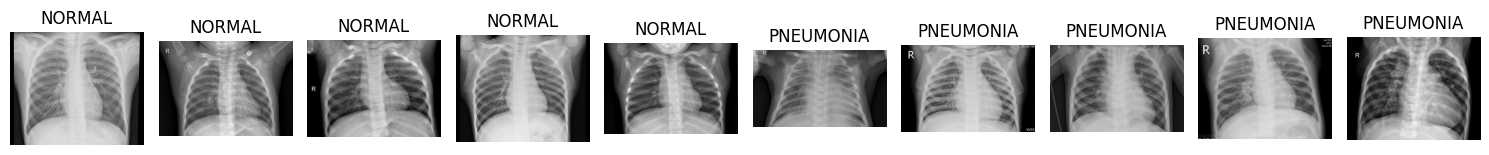

In [20]:
import matplotlib.pyplot as plt
import random

def display_sample_images(data_dir, num_images=5):
    """Displays a few sample images from the NORMAL and PNEUMONIA classes."""
    normal_dir = os.path.join(data_dir, 'test', 'NORMAL')
    pneumonia_dir = os.path.join(data_dir, 'test', 'PNEUMONIA')

    normal_images = [os.path.join(normal_dir, img) for img in os.listdir(normal_dir) if img.endswith('.jpeg')]
    pneumonia_images = [os.path.join(pneumonia_dir, img) for img in os.listdir(pneumonia_dir) if img.endswith('.jpeg')]

    sample_normal = random.sample(normal_images, min(num_images, len(normal_images)))
    sample_pneumonia = random.sample(pneumonia_images, min(num_images, len(pneumonia_images)))

    plt.figure(figsize=(15, 5))

    for i, img_path in enumerate(sample_normal):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(1, num_images * 2, i + 1)
        plt.imshow(img)
        plt.title('NORMAL')
        plt.axis('off')

    for i, img_path in enumerate(sample_pneumonia):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(1, num_images * 2, i + num_images + 1)
        plt.imshow(img)
        plt.title('PNEUMONIA')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

display_sample_images(DATA_DIR)

In [18]:
# Example Usage: Predict on a sample image
sample_image_path = os.path.join(DATA_DIR, 'test', 'PNEUMONIA', os.listdir(os.path.join(DATA_DIR, 'test', 'PNEUMONIA'))[0]) # Using the first pneumonia image in the test set as an example
prediction_result = predict_pneumonia(sample_image_path, model)
print(prediction_result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Pneumonia detected with confidence: 98.95%


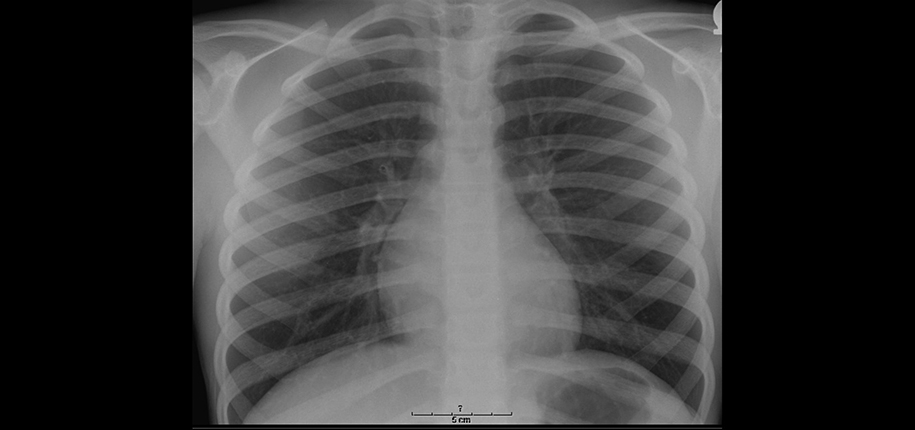

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Pneumonia detected with confidence: 68.65%


In [26]:
# Replace "path/to/your/image.jpg" with the actual path to your image file
your_image_path = "/content/images.jpeg"
your_image_path = "/content/Chest-X-ray-normal.jpeg"

# Display the image
from IPython.display import Image, display
display(Image(filename=your_image_path))

# Get and print the prediction
prediction_result = predict_pneumonia(your_image_path, model)
print(prediction_result)

Saving images.jpeg to images (2).jpeg
Processing uploaded file: images (2).jpeg


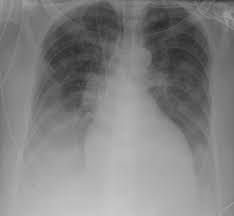

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Prediction for images (2).jpeg: Pneumonia detected with confidence: 97.87%


In [31]:
from google.colab import files
from IPython.display import Image, display
import os

uploaded = files.upload()

for filename in uploaded.keys():
  print(f'Processing uploaded file: {filename}')
  try:
    # Display the image
    display(Image(filename))

    # Get and print the prediction
    prediction_result = predict_pneumonia(filename, model)
    print(f"Prediction for {filename}: {prediction_result}")

  except Exception as e:
    print(f"Could not process {filename}: {e}")

# Task
Use an API key to fetch chest X-ray images and train a model.

## Research apis

### Subtask:
Identify and research relevant APIs that provide access to chest X-ray images. Evaluate their terms of service, data availability, and access methods.


## Obtain api key

### Subtask:
If required, obtain an API key or credentials to access the chosen API.


## Develop data fetching script

### Subtask:
Write a Python script to connect to the API, fetch images based on criteria (e.g., normal/pneumonia), and save them locally.


## Integrate with training pipeline

### Subtask:
Modify the existing data loading and preprocessing steps to use the newly fetched images.


**Reasoning**:
Update the DATA_DIR variable and modify the ImageDataGenerator calls to use the new data directory.



In [32]:
# Assume the new fetched images are saved in a directory named 'new_chest_xray'
# within the kaggle input directory. Update DATA_DIR accordingly.
DATA_DIR = '/kaggle/input/chest-xray-pneumonia/new_chest_xray' # This needs to be the correct path

try:
    train_generator = train_datagen.flow_from_directory(
        os.path.join(DATA_DIR, 'train'),
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='binary'
    )

    val_generator = val_datagen.flow_from_directory(
        os.path.join(DATA_DIR, 'val'),
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='binary'
    )

    test_generator = test_datagen.flow_from_directory(
        os.path.join(DATA_DIR, 'test'),
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='binary',
        shuffle=False
    )
except Exception as e:
    print(f"Error loading data: {e}")
    print("Please ensure your dataset is correctly organized at the specified path.")
    # Exit is not supported in this environment, reporting failure
    print("Subtask failed: Error loading data.")

Error loading data: [Errno 2] No such file or directory: '/kaggle/input/chest-xray-pneumonia/new_chest_xray/train'
Please ensure your dataset is correctly organized at the specified path.
Subtask failed: Error loading data.


## Retrain the model

### Subtask:
Retrain the existing model or a new model using the expanded dataset.


**Reasoning**:
Re-compile and train the existing model using the specified parameters.



In [33]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

print("\nStarting model training...")
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=val_generator,
    validation_steps=val_generator.samples // BATCH_SIZE
)


Starting model training...
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 76s 443ms/step - accuracy: 0.9142 - loss: 0.2107 - val_accuracy: 0.7500 - val_loss: 0.8222
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 74s 447ms/step - accuracy: 0.9174 - loss: 0.2095 - val_accuracy: 0.7500 - val_loss: 0.7437
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 72s 443ms/step - accuracy: 0.9176 - loss: 0.2037 - val_accuracy: 0.8125 - val_loss: 0.7094
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 435ms/step - accuracy: 0.9304 - loss: 0.1639 - val_accuracy: 0.7500 - val_loss: 0.4383
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 84s 449ms/step - accuracy: 0.9269 - loss: 0.1898 - val_accuracy: 0.8125 - val_loss: 0.8790
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 83s 458ms/step - accuracy: 0.9346 - loss: 0.1654 - val_accuracy: 0.8750 - val_loss: 0.3353
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 78s 435ms/step - accuracy: 0.9165 - loss: 0.1935 - val_accuracy: 0.8125 - val_loss: 0.3235
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 436ms/step 